## **Water Quality Assessment Using Machine Learning **

In [ ]:
#machine learning practise model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
water_data=pd.read_csv('water_potability.csv')
water_data.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
water_data.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

In [ ]:
water_data.dtypes

,0
ph,float64
Hardness,float64
Solids,float64
Chloramines,float64
Sulfate,float64
Conductivity,float64
Organic_carbon,float64
Trihalomethanes,float64
Turbidity,float64
Potability,int64


In [ ]:
water_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [ ]:
water_data.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


<Axes: xlabel='ph', ylabel='Count'>

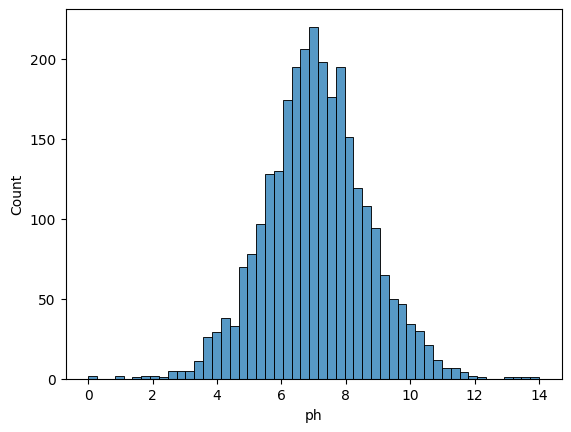

In [ ]:
#now to handle missing values

sns.histplot(water_data['ph'])

#all well distributed

<Axes: xlabel='Sulfate', ylabel='Count'>

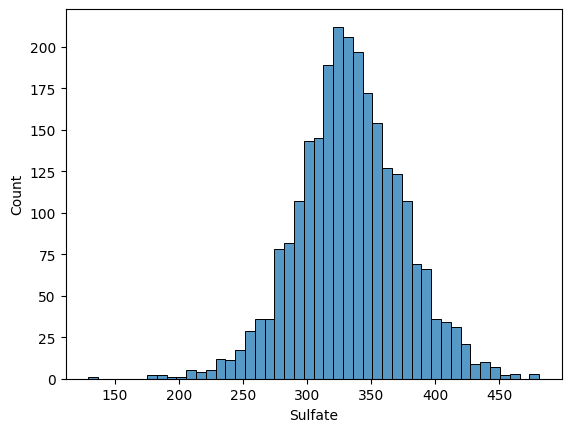

In [ ]:
sns.histplot(water_data['Sulfate'])
#all well distributed

<Axes: xlabel='Trihalomethanes', ylabel='Count'>

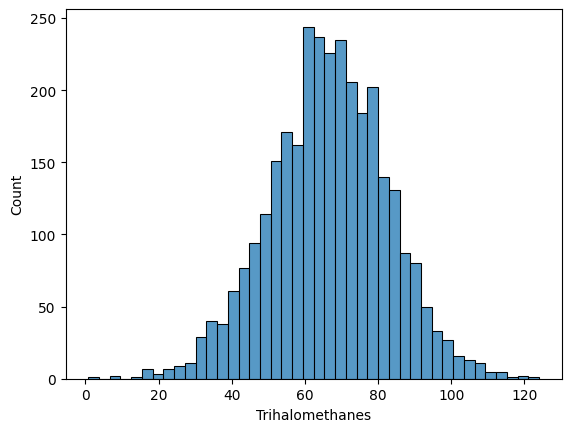

In [ ]:
sns.histplot(water_data['Trihalomethanes'])
#all well distributed

In [ ]:
#replacing null value to the mean of its col

water_data['ph']=water_data['ph'].fillna(water_data['ph'].mean())
water_data['Sulfate']=water_data['Sulfate'].fillna(water_data['Sulfate'].mean())
water_data['Trihalomethanes']=water_data['Trihalomethanes'].fillna(water_data['Trihalomethanes'].mean())

In [ ]:
water_data.isnull().sum()

# no null cell left

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


In [ ]:
#now checking for correlation

corr_matrix=water_data.corr()
corr_matrix

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
ph,1.000000,0.075833,-0.081884,-0.031811,0.014403,0.017192,0.040061,0.002994,-0.036222,-0.003287
Hardness,0.075833,1.000000,-0.046899,-0.030054,-0.092766,-0.023915,0.003610,-0.012690,-0.014449,-0.013837
Solids,-0.081884,-0.046899,1.000000,-0.070148,-0.149840,0.013831,0.010242,-0.008875,0.019546,0.033743
Chloramines,-0.031811,-0.030054,-0.070148,1.000000,0.023791,-0.020486,-0.012653,0.016627,0.002363,0.023779
Sulfate,0.014403,-0.092766,-0.149840,0.023791,1.000000,-0.014059,0.026909,-0.025605,-0.009790,-0.020619
Conductivity,0.017192,-0.023915,0.013831,-0.020486,-0.014059,1.000000,0.020966,0.001255,0.005798,-0.008128
Organic_carbon,0.040061,0.003610,0.010242,-0.012653,0.026909,0.020966,1.000000,-0.012976,-0.027308,-0.030001
Trihalomethanes,0.002994,-0.012690,-0.008875,0.016627,-0.025605,0.001255,-0.012976,1.000000,-0.021502,0.006960
Turbidity,-0.036222,-0.014449,0.019546,0.002363,-0.009790,0.005798,-0.027308,-0.021502,1.000000,0.001581
Potability,-0.003287,-0.013837,0.033743,0.023779,-0.020619,-0.008128,-0.030001,0.006960,0.001581,1.000000


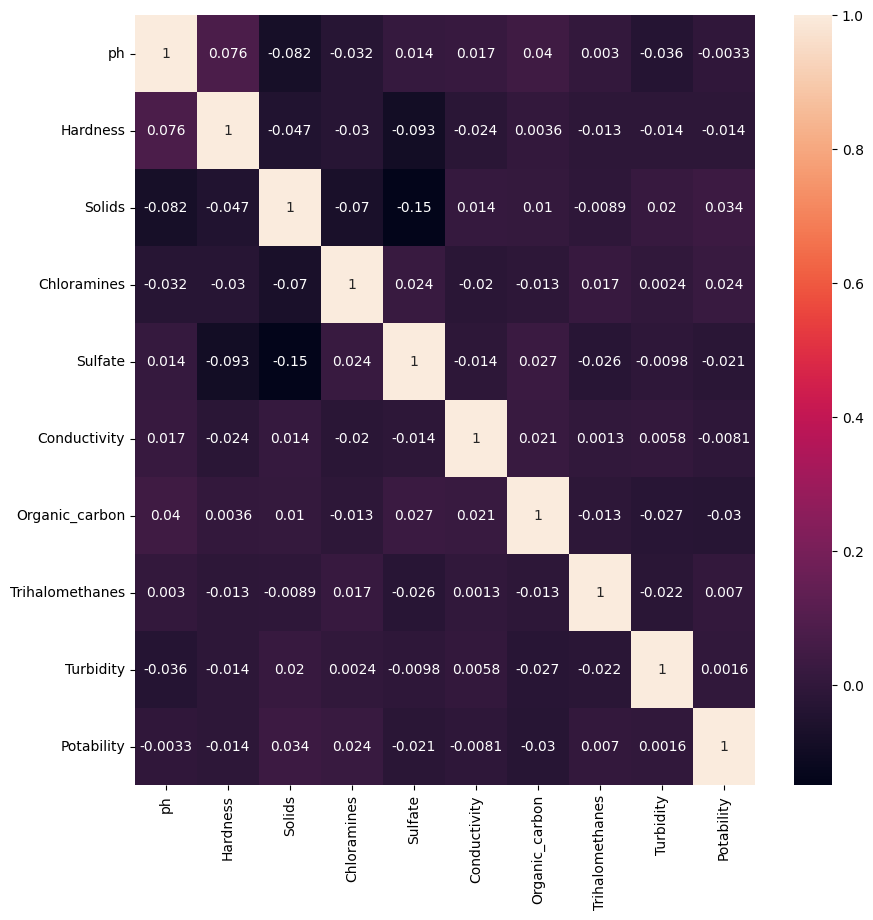

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix,annot=True)
plt.show()

#not finding any relation

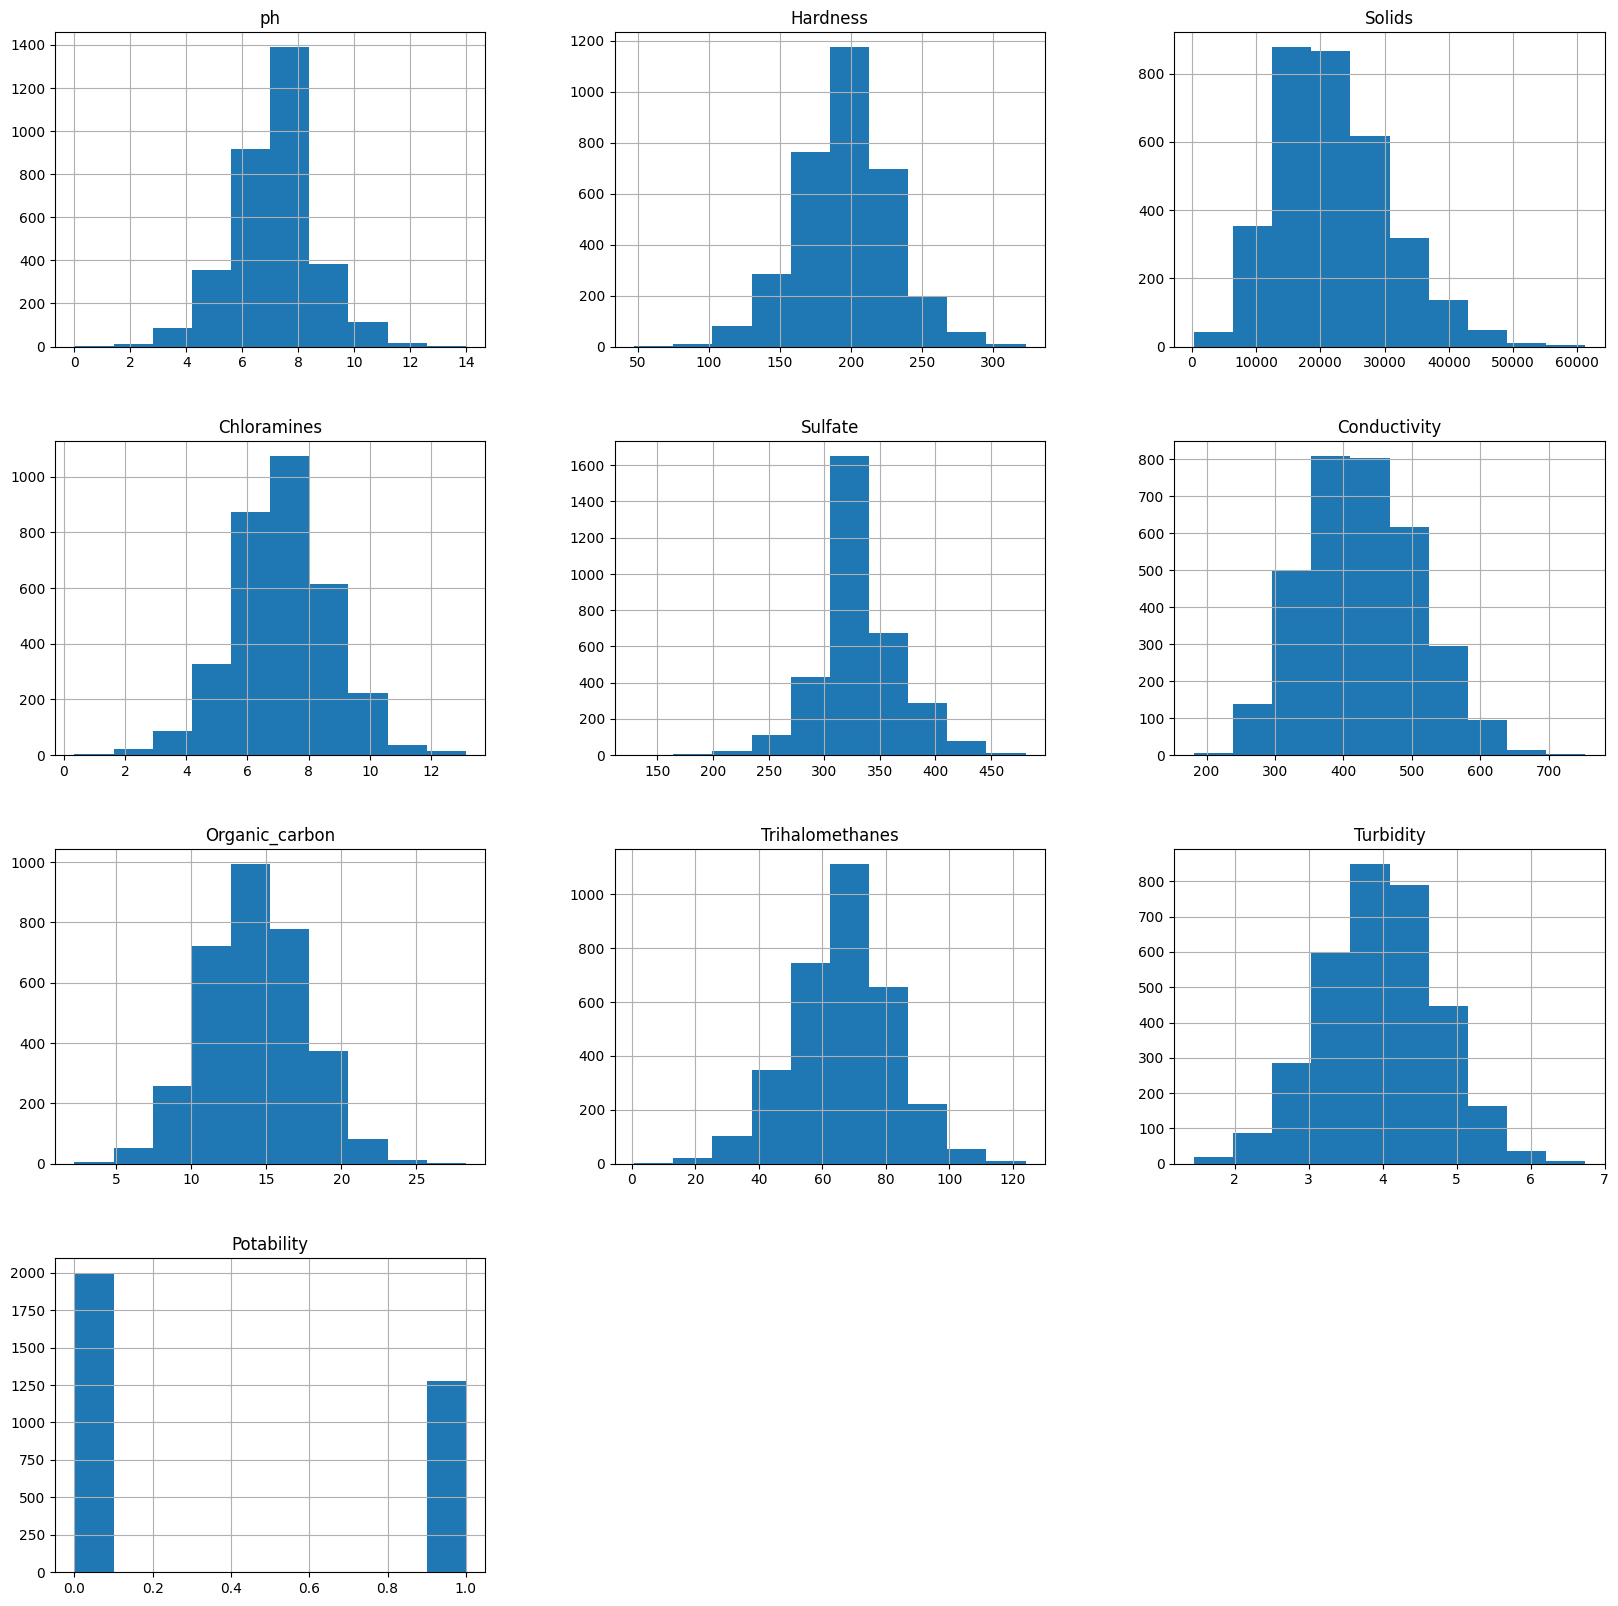

In [ ]:
data_plot=water_data.hist(figsize=(20,20))
#not found much outliers

In [ ]:
data_value=water_data.drop('Potability',axis=1)
data_target=water_data['Potability']

In [ ]:
#feature scaling

from sklearn.preprocessing import StandardScaler
std_scaler=StandardScaler()
data_value_scaled=std_scaler.fit_transform(data_value)
data_value_scaled

array([[-6.04313345e-16,  2.59194711e-01, -1.39470871e-01, ...,
        -1.18065057e+00,  1.30614943e+00, -1.28629758e+00],
       [-2.28933938e+00, -2.03641367e+00, -3.85986650e-01, ...,
         2.70597240e-01, -6.38479983e-01,  6.84217891e-01],
       [ 6.92867789e-01,  8.47664833e-01, -2.40047337e-01, ...,
         7.81116857e-01,  1.50940884e-03, -1.16736546e+00],
       ...,
       [ 1.59125368e+00, -6.26829230e-01,  1.27080989e+00, ...,
        -9.81329234e-01,  2.18748247e-01, -8.56006782e-01],
       [-1.32951593e+00,  1.04135450e+00, -1.14405809e+00, ...,
        -9.42063817e-01,  7.03468419e-01,  9.50797383e-01],
       [ 5.40150905e-01, -3.85462310e-02, -5.25811937e-01, ...,
         5.60940070e-01,  7.80223466e-01, -2.12445866e+00]])

In [ ]:
#spliting in training and testing

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(data_value_scaled,data_target,test_size=0.2,random_state=42,stratify=data_target)

x_train.shape,x_test.shape,y_train.shape,y_test.shape

((2620, 9), (656, 9), (2620,), (656,))

In [ ]:
#creating a random forest classifier model

from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier()
rfc.fit(x_train,y_train)


RandomForestClassifier()

In [ ]:
rfc.score(x_test,y_test)*100

65.85365853658537

In [ ]:
#extra for me

import pandas as pd


importances = rfc.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': data_value.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

           Feature  Importance
4          Sulfate    0.128091
0               ph    0.127238
1         Hardness    0.122997
3      Chloramines    0.114519
2           Solids    0.110748
8        Turbidity    0.102508
5     Conductivity    0.100972
6   Organic_carbon    0.097922
7  Trihalomethanes    0.095006
